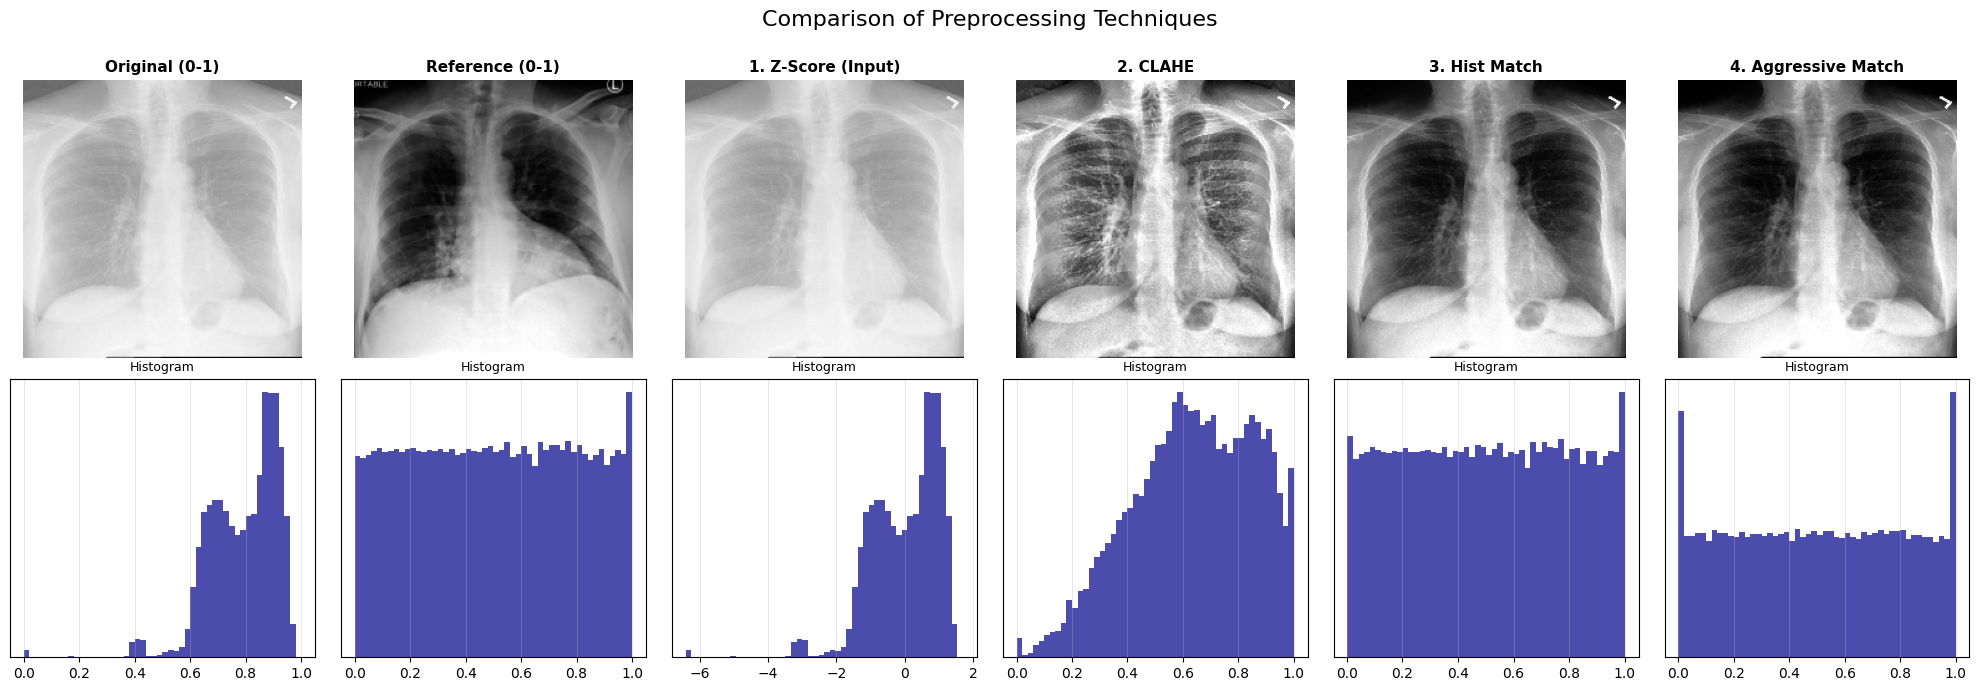

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.exposure import equalize_adapthist, rescale_intensity, equalize_hist
import os

# --- 1. CONFIGURATION ---
REF_PATH = "dataset/reference1249.npy" 
TEST_PATH = "dataset/mdrc_seg/0/1.2.826.0.1.3680043.10.474.419639.334590694161596573057714909031.npy" 

# --- 2. ROBUST IMPORTS ---
try:
    from skimage.exposure import match_histograms
except ImportError:
    from skimage.transform import match_histograms

# --- 3. HELPER FUNCTIONS ---

def normalize_01(img):
    """
    Normalizes image to 0.0 - 1.0 range.
    CRITICAL for skimage functions to work without errors.
    """
    if img.max() == img.min(): return img # Avoid division by zero
    return (img - img.min()) / (img.max() - img.min())

def load_npy(path):
    img = np.load(path)
    if len(img.shape) == 3: img = img[:,:,0] # Force 2D
    img = img.astype(np.float32)
    # FIX: Normalize immediately so skimage doesn't crash
    return normalize_01(img)

def standardization(img):
    # Z-Score (For the Neural Network, not for plotting)
    return (img - img.mean()) / (img.std() + 1e-8)

def aggressive_match(source, reference):
    """
    Clamps top/bottom 2% outliers BEFORE matching. 
    """
    # 1. Clamp Source
    s_p2, s_p98 = np.percentile(source, (2, 98))
    source_c = rescale_intensity(source, in_range=(s_p2, s_p98), out_range='dtype')
    
    # 2. Clamp Reference
    r_p2, r_p98 = np.percentile(reference, (2, 98))
    ref_c = rescale_intensity(reference, in_range=(r_p2, r_p98), out_range='dtype')
    
    # 3. Match
    try:
        matched = match_histograms(source_c, ref_c, channel_axis=None)
    except TypeError:
        matched = match_histograms(source_c, ref_c, multichannel=False)
        
    return matched

# --- 4. LOAD IMAGES ---
if not os.path.exists(REF_PATH) or not os.path.exists(TEST_PATH):
    print("❌ ERROR: Please check your file paths in Section 1.")
else:
    # They are now automatically normalized to 0-1 by load_npy
    ref_img = load_npy(REF_PATH)
    test_img = load_npy(TEST_PATH)

    # --- 5. APPLY TECHNIQUES ---
    
    # A. Baseline (Z-Score)
    # Note: This pushes values outside [0,1], so we don't put it into skimage functions
    res_std = standardization(test_img)
    
    # B. Histogram Equalization (Global)
    res_hist = equalize_hist(test_img)
    
    # C. CLAHE (Adaptive Equalization)
    # Now works because test_img is 0.0 - 1.0
    res_clahe = equalize_adapthist(test_img, clip_limit=0.03)
    
    # D. Simple Histogram Matching
    try:
        res_match = match_histograms(test_img, ref_img, channel_axis=None)
    except TypeError:
        res_match = match_histograms(test_img, ref_img, multichannel=False)
        
    # E. Aggressive Matching (Clamp + Match)
    res_agg = aggressive_match(test_img, ref_img)
# --- 6. VISUALIZATION (FIXED LAYOUT) ---
    techniques = [
        ("Original (0-1)", test_img),
        ("Reference (0-1)", ref_img),
        ("1. Z-Score (Input)", res_std),
        ("2. CLAHE", res_clahe),
        ("3. Hist Match", res_match),
        ("4. Aggressive Match", res_agg)
    ]

    # Create a figure with 2 rows and 6 columns
    # Row 1: Images
    # Row 2: Histograms
    fig, axes = plt.subplots(2, 6, figsize=(20, 7))
    
    # Flatten axes for easy indexing if needed, but we can index [row, col]
    for i, (name, img) in enumerate(techniques):
        
        # --- ROW 1: IMAGES ---
        ax_img = axes[0, i]
        ax_img.imshow(img, cmap='gray')
        ax_img.set_title(f"{name}", fontsize=11, fontweight='bold')
        ax_img.axis('off')
        
        # --- ROW 2: HISTOGRAMS ---
        ax_hist = axes[1, i]
        # Use simple matplotlib hist for speed and clarity
        ax_hist.hist(img.flatten(), bins=50, color='darkblue', alpha=0.7, density=True)
        ax_hist.set_title("Histogram", fontsize=9)
        ax_hist.set_yticks([]) # Hide Y axis numbers to save space
        
        # Add a grid to see distribution width easier
        ax_hist.grid(True, alpha=0.3)

    plt.suptitle("Comparison of Preprocessing Techniques", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.88) # Make space for main title
    plt.show()

In [6]:
arr = np.load("dataset/ready_to_train/train/0/A418141-1-1.npy")
print(arr.shape)

(224, 224)
